---
numbering: false
---

# 5.2. Diagonalization

In [Chapter 5.1](01-intro) and [Chapter 5.1, Part 2](015-adjacency-matrices), we saw that eigenvalues and eigenvectors allow us to better understand the behavior of the linear transformation from $\mathbb{R}^n$ to $\mathbb{R}^n$ given by an $n \times n$ matrix $A$. 

When understanding matrix powers and adjacency matrices, we often decomposed some arbitrary vector $\vec x$ as a linear combination of eigenvectors of $A$. But sometimes, the eigenvectors of $A$ don't span all of $\mathbb{R}^n$, meaning we can't write every other vector as a linear combination of eigenvectors of $A$. When does this happen, and why do we really care?

---

## The Eigenvector Decomposition

Recall that if $A$ is an $n \times n$ matrix, then $A$ has $n$ eigenvalues, it's just that some of the eigenvalues may be complex (leading to complex-valued eigenvectors), and some eigenvalues may be repeated. These $n$ eigenvalues are all solutions to the characteristic polynomial of $A$,

$$p(\lambda) = \text{det}(A - \lambda I)$$

The corresponding eigenvectors are the solutions to the system of equations $(A - \lambda I) \vec v = \vec 0$.

Suppose $A$ has $n$ linearly independent eigenvectors $\vec v_1, \vec v_2, \cdots, \vec v_n$, with eigenvalues $\lambda_1, \lambda_2, \cdots, \lambda_n$. What I'm about to propose next will seem a little arbitrary, but bear with me – you'll see the power of this idea shortly. What happens if we multiply $A$ by a **matrix**, say $V$, whose columns are the eigenvectors of $A$?

\begin{align*}
AV &= A \begin{bmatrix} | & | && | \\ \vec v_1 & \vec v_2 & \cdots & \vec v_n \\ | & | && | \end{bmatrix} \\
   &= \begin{bmatrix} | & | && | \\ A\vec v_1 & A\vec v_2 & \cdots & A\vec v_n \\ | & | && | \end{bmatrix} \\
   &= \begin{bmatrix} | & | && | \\ \lambda_1 \vec v_1 & \lambda_2 \vec v_2 & \cdots & \lambda_n \vec v_n \\ | & | && | \end{bmatrix}
\end{align*}

$AV$ is a matrix whose columns are eigenvectors of $A$, each scaled by the corresponding eigenvalue! Is there another way to write the last line above?

\begin{align*}
AV &= \begin{bmatrix} | & | && | \\ \lambda_1 \vec v_1 & \lambda_2 \vec v_2 & \cdots & \lambda_n \vec v_n \\ | & | && | \end{bmatrix} \\
   &= \begin{bmatrix} | & | && | \\ \vec v_1 & \vec v_2 & \cdots & \vec v_n \\ | & | && | \end{bmatrix} \begin{bmatrix} \lambda_1 & 0 & \cdots & 0 \\ 0 & \lambda_2 & \cdots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \cdots & \lambda_n \end{bmatrix} \\
   &= V \Lambda
\end{align*}

Here, $\mathcal{\Lambda}$ (the capitalized Greek letter for $\mathbf{\lambda}$) is a diagonal matrix of eigenvalues **in the same order as the eigenvectors in $V$**.

$$AV = V \Lambda$$

We can take this a step further. **If** $V$ is invertible – which it is here, since we assumed $A$ has $n$ linearly independent eigenvectors – then we can multiply both sides of the equation above by $V^{-1}$ on the right to get

$$A = V \Lambda V^{-1}$$

The existence of this decomposition is contingent on $V$ being invertible, **which happens when $A$ has $n$ linearly independent eigenvectors**. If $A$ doesn't have "enough" eigenvectors, then $V$ wouldn't be invertible, and we wouldn't be able to decompose $A$ in this way.

### Diagonalizable Matrices

:::{note} Definition: Eigenvalue Decomposition

The **eigenvalue decomposition** of a matrix $A$ is a decomposition of the form $$A = V \Lambda V^{-1}$$ where $V$ is a matrix containing the eigenvectors of $A$ as columns, and $\mathcal{\Lambda}$ is a diagonal matrix of eigenvalues in the same order.
:::

:::{note} Definition: Diagonalizable Matrix

A matrix $A$ is **diagonalizable** if it has an eigenvalue decomposition $$A = V \Lambda V^{-1}$$ using the same definitions of $V$ and $\mathcal{\Lambda}$ above. $A$ is diagonalizable if and only if it has $n$ linearly independent eigenvectors (which allows for $V$ to be invertible). Otherwise, $A$ is not diagonalizable, and is sometimes called **defective**.

Often, $A$ is defined to be diagonalizable if and only if it can be written in the form $$A = PDP^{-1}$$ where $P$ is _some_ invertible matrix and $D$ is _some_ diagonal matrix. This is a general definition of diagonalizability. But, **the only matrices that can be written in $A = PDP^{-1}$ have eigenvalue decompositions and vice versa**. The eigenvalue decomposition tells you how to actually diagonalize $A$.
:::

### A First Example

Let's start with a familiar example, $A = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix}$, which was the first example we saw in [Chapter 5.1](01-intro). $A$ has eigenvalues $\lambda_1 = 3$ and $\lambda_2 = -1$, and corresponding eigenvectors $\vec v_1 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}$ and $\vec v_2 = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$. These eigenvectors are linearly independent, so $A$ is diagonalizable, and we can write

$$V = \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}, \qquad \Lambda = \begin{bmatrix} 3 & 0 \\ 0 & -1 \end{bmatrix}$$

which tells us that

$$V \Lambda V^{-1} = \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix} \begin{bmatrix} 3 & 0 \\ 0 & -1 \end{bmatrix} \begin{bmatrix} 1/2 & 1/2 \\ 1/2 & -1/2 \end{bmatrix} = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix} = A$$

Let's check with `numpy`.

In [4]:
import numpy as np

In [11]:
V = np.array([[1, 1], 
              [1, -1]])

Lambda = np.diag([3, -1]) # New tool.
V_inv = np.linalg.inv(V)
V @ Lambda @ V_inv # The same as A!

array([[1., 2.],
       [2., 1.]])

Is this decomposition unique? No, because we could have chosen a different set of eigenvectors, or wrote them in a different order (in which case $\mathcal{\Lambda}$ would be different). We'll keep the eigenvectors in the same order, but instead let's consider

$$V = \begin{bmatrix} 2 & -5 \\ 2 & 5 \end{bmatrix}$$

which is also a valid eigenvector matrix for $A$. (Remember that any scalar multiple of an eigenvector is still an eigenvector!)

It is **still** true that $A = V \Lambda V^{-1}$. This may seem a little unbelievable (I wasn't convinced at first), but remember that $V^{-1}$ "undoes" any changes in scaling we introduce to $V$.

$$V \Lambda V^{-1} = \begin{bmatrix} 2 & -5 \\ 2 & 5 \end{bmatrix} \begin{bmatrix} 3 & 0 \\ 0 & -1 \end{bmatrix} \begin{bmatrix} 1/4 & 1/4 \\ -1/10 & 1/10 \end{bmatrix} = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix} = A$$

In [ ]:
V = np.array([[2, -5], 
              [2, 5]])
              
Lambda = np.diag([3, -1])
V_inv = np.linalg.inv(V)
V @ Lambda @ V_inv # Same as above!

array([[1., 2.],
       [2., 1.]])

---

## Key Applications

Rightfully, you might be asking what the point of this is. There are (at least) two main uses of the eigenvalue decomposition. 

### Application 1: Matrix Powers

The first is that it makes it easy to compute powers of $A$, which we know is a useful concept in understanding the long-run behavior of a Markov chain.

Suppose $A = V \Lambda V^{-1}$. Then,

$$A^2 = (V \Lambda V^{-1})(V \Lambda V^{-1}) = V \Lambda (V^{-1}V) \Lambda V^{-1} = V \Lambda^2 V^{-1}$$

What does this say about $A^3$?

$$A^3 = (V \Lambda V^{-1})(V \Lambda V^{-1})(V \Lambda V^{-1}) = V \Lambda (V^{-1}V) \Lambda (V^{-1}V) \Lambda V^{-1} = V \Lambda^3 V^{-1}$$

In general, if $k$ is a positive integer,

$$\boxed{A^k = V \Lambda^k V^{-1}}$$

So, to compute $A^k$, we don't need to multiply $k$ matrices together (which would be a computational nightmare for large $k$). Instead, all we need to do is compute $V \Lambda^k V^{-1}$. And remember, $\mathcal{\Lambda}$ is a diagonal matrix, so computing $\Lambda^k$ is easy: we just raise the diagonal entries to the power in question.

For example, $A^{10} = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix}^{10}$ is 

\begin{align*}
A^{10} &= V \Lambda^{10} V^{-1} \\
&= \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix} 
   \begin{bmatrix} 3^{10} & 0 \\ 0 & (-1)^{10} \end{bmatrix} 
   \begin{bmatrix} 1/2 & 1/2 \\ 1/2 & -1/2 \end{bmatrix} \\
   &= \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}
      \begin{bmatrix} 3^{10}/2 & 3^{10}/2 \\1 /2 & -1/2 \end{bmatrix} \\
   &= \begin{bmatrix} (3^{10} + 1)/2 & (3^{10} - 1)/2 \\ (3^{10} - 1)/2 & (3^{10} + 1)/2 \end{bmatrix}
\end{align*}

Pretty neat!

In [22]:
np.linalg.matrix_power(A, 10)

array([[29525., 29524.],
       [29524., 29525.]])

### Application 2: Understanding Linear Transformations

Remember that if $A$ is an $n \times n$ matrix, then $f(\vec x) = A \vec x$ is a linear transformation from $\mathbb{R}^n$ to $\mathbb{R}^n$. But, if $A = V \Lambda V^{-1}$, then

$$f(\vec x) = A \vec x = V \Lambda V^{-1} \vec x$$

This allows us to understand the effect of $f$ on $\vec x$ in three stages. Remember that $V$'s columns are the eigenvectors of $A$, so the act of multiplying a vector $\vec y$ by $V$ is equivalent to taking a linear combination of $V$'s columns ($A$'s eigenvectors) using the weights in $\vec y$.

$$V \vec y = \begin{bmatrix} | & | & \cdots & | \\ \vec v_1 & \vec v_2 & \cdots & \vec v_n \\ | & | & \cdots & | \end{bmatrix} \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix} = y_1 \vec v_1 + y_2 \vec v_2 + \cdots + y_n \vec v_n$$

$\vec y$ contains the amount of each eigenvector we'd like to scale by; for instance, $V \begin{bmatrix} 3 \\ -4 \end{bmatrix}$ says take 3 of the first eigenvector, and -4 of the second eigenvector, and add them together to get a new vector.

Intuitively, think of $V$ as a matrix that takes in "amounts of each eigenvector" and outputs "amounts of each standard basis vector", where the standard basis vectors are the columns of $I$.

So, if $$V: \text{eigenvector amounts} \to \text{standard basis vector amounts}$$ then $V^{-1}$ does the opposite, and maps $$V^{-1}: \text{standard basis vector weights} \to \text{eigenvector amounts}$$ 

i.e. multiplying $V^{-1}$ by $\vec x$ **expresses $\vec x$ as a linear combination of the eigenvectors of $A$**. If $\vec z$ is the output of $V^{-1} \vec x$, then $\vec x = V \vec z$, meaning $\vec z$ contains the amounts of each eigenvector needed to produce $\vec x$.

(This is non-standard notation, since $V$ is not a function and $\text{eigenvector amounts}$ and $\text{standard basis vector amounts}$ are not sets but concepts, but I hope this helps convey the role of $V$ and $V^{-1}$ in this context.)

Taking a step back, recall

$$f(\vec x) = A \vec x = V \Lambda V^{-1} \vec x$$

What this is saying is $f$ does three things:
1. First, it takes $\vec x$ and expresses it as a linear combination of the eigenvectors of $A$.
1. Then, it takes that linear combination $V^{-1} \vec x$ and scales each eigenvector by its corresponding eigenvalue, i.e. it **stretches** the eigenvectors by different amounts.
1. Finally, it takes the resulting stretched vector $\Lambda V^{-1} \vec x$ and expresses it as a linear combination of the standard basis vectors, i.e. it combines the correct amounts of the stretched eigenvectors to get the final result.

$$\underbrace{\text{express in eigenvector basis}}_{\text{multiply by } V^{-1}} \to \underbrace{\text{scale eigenvectors}}_{\text{multiply by } \Lambda} \to \underbrace{\text{express in standard basis}}_{\text{multiply by } V}$$

This is better understood visually (coming soon!).

In [27]:
# import numpy as np
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots
# from utils import plot_vectors

# def plot_unit_square_and_transform(S, name="Matrix", vdeltax=-0.3, vdeltay=0.2, return_fig=False):
#     # Vertices of the unit square
#     square = np.array([
#         [0, 0],  # A
#         [1, 0],  # B
#         [1, 1],  # C
#         [0, 1],  # D
#         [0, 0]   # A (to close the square)
#     ])
#     # Transformed square
#     square_trans = (S @ square.T).T

#     # Create subplot figure
#     fig = make_subplots(
#         rows=1, cols=2,
#         subplot_titles=(r"$$\vec u_x \text{  and } \vec u_y$$", fr"$${name}" + r"\vec u_x \text{  and }" + fr"{name} \vec u_y$$"),
#         horizontal_spacing=0.08
#     )

#     # Common axis settings
#     axis_style = dict(
#         showgrid=True,
#         gridcolor="#f0f0f0",
#         zeroline=False,  # We'll add our own zero lines
#         showline=True,
#         linecolor="#f0f0f0",
#         mirror=True,
#         ticks="outside",
#         showticklabels=True,
#         tickfont=dict(family="Palatino, serif", size=14),
#     )

#     # Set axis ranges to [-2.5, 2.5] for both subplots
#     for i in [1, 2]:
#         fig.update_xaxes(
#             range=[-2.5, 2.5],
#             constrain="domain",
#             dtick=1,
#             **axis_style,
#             row=1, col=i
#         )
#         fig.update_yaxes(
#             range=[-2.5, 2.5],
#             scaleanchor=f"x{i}",
#             dtick=1,
#             **axis_style,
#             row=1, col=i
#         )

#     # --- Draw faint 0 grid lines underneath everything else ---
#     for i in [1, 2]:
#         # Horizontal y=0
#         fig.add_shape(
#             type="line",
#             x0=-2.5, x1=2.5, y0=0, y1=0,
#             line=dict(color="rgba(170,170,170,0.25)", width=2, dash="solid"),
#             row=1, col=i,
#             layer="below"
#         )
#         # Vertical x=0
#         fig.add_shape(
#             type="line",
#             x0=0, x1=0, y0=-2.5, y1=2.5,
#             line=dict(color="rgba(170,170,170,0.25)", width=2, dash="solid"),
#             row=1, col=i,
#             layer="below"
#         )

#     # Plot original unit square (no perimeter, low opacity)
#     fig.add_trace(
#         go.Scatter(
#             x=square[:,0], y=square[:,1],
#             fill="toself",
#             fillcolor="rgba(61,129,246,0.4)",
#             line=dict(color="rgba(0,0,0,0)", width=0),  # No perimeter
#             name="Unit Square",
#             showlegend=False
#         ),
#         row=1, col=1
#     )

#     # Plot transformed square (no perimeter, low opacity)
#     fig.add_trace(
#         go.Scatter(
#             x=square_trans[:,0], y=square_trans[:,1],
#             fill="toself",
#             fillcolor="rgba(255,140,0,0.4)",
#             line=dict(color="rgba(0,0,0,0)", width=0),  # No perimeter
#             name="Transformed Square",
#             showlegend=False
#         ),
#         row=1, col=2
#     )

#     # --- Draw vectors using plot_vectors ---
#     # Standard basis vectors
#     u_x = np.array([1, 0])
#     u_y = np.array([0, 1])
#     # Transformed basis vectors
#     Su_x = S @ u_x
#     Su_y = S @ u_y

#     # Left: u_x, u_y in #3d81f6
#     left_vecs = [
#         (tuple(u_x), '#3d81f6', r'$\vec u_x$'),
#         (tuple(u_y), '#3d81f6', r'$\vec u_y$')
#     ]
#     left_fig = plot_vectors(left_vecs, vdeltay=-0.2)
#     # Remove background, axes, and grid from plot_vectors output
#     left_fig.update_layout(
#         plot_bgcolor="rgba(0,0,0,0)",
#         paper_bgcolor="rgba(0,0,0,0)",
#         xaxis=dict(visible=False),
#         yaxis=dict(visible=False),
#         margin=dict(l=0, r=0, t=0, b=0)
#     )
#     # Add the vector traces to the left subplot
#     for trace in left_fig.data:
#         fig.add_trace(trace, row=1, col=1)
#     # Add the vector annotations to the left subplot
#     for ann in left_fig.layout.annotations:
#         # Convert Plotly Annotation object to dict safely
#         if hasattr(ann, "to_plotly_json"):
#             ann_dict = ann.to_plotly_json()
#         else:
#             ann_dict = dict(ann)
#         # Remove keys that are not valid for add_annotation
#         ann_dict = {k: v for k, v in ann_dict.items() if k not in {"xref", "yref", "axref", "ayref"}}
#         fig.add_annotation(**ann_dict, row=1, col=1)

#     # Right: Su_x, Su_y in orange, with correct labels
#     right_vecs = [
#         (tuple(Su_x), 'orange', rf'${name} \vec u_x$'),
#         (tuple(Su_y), 'orange', rf'${name} \vec u_y$')
#     ]
#     right_fig = plot_vectors(right_vecs, vdeltax=vdeltax, vdeltay=vdeltay)
#     right_fig.update_layout(
#         plot_bgcolor="rgba(0,0,0,0)",
#         paper_bgcolor="rgba(0,0,0,0)",
#         xaxis=dict(visible=False),
#         yaxis=dict(visible=False),
#         margin=dict(l=0, r=0, t=0, b=0)
#     )
#     for trace in right_fig.data:
#         fig.add_trace(trace, row=1, col=2)
#     for ann in right_fig.layout.annotations:
#         # Convert Plotly Annotation object to dict safely
#         if hasattr(ann, "to_plotly_json"):
#             ann_dict = ann.to_plotly_json()
#         else:
#             ann_dict = dict(ann)
#         # Remove keys that are not valid for add_annotation
#         ann_dict = {k: v for k, v in ann_dict.items() if k not in {"xref", "yref", "axref", "ayref"}}
#         fig.add_annotation(**ann_dict, row=1, col=2)

#     fig.update_layout(
#         font=dict(family="Palatino, serif", size=16),
#         plot_bgcolor="white",
#         paper_bgcolor="white",
#         margin=dict(l=20, r=20, t=40, b=20),
#         width=800, height=400,
#     )

#     if return_fig:
#         return fig
#     fig.show(renderer='png', scale=3)

# # Example usage:
# A = np.array([[2, 0], [0, -1/3]])
# plot_unit_square_and_transform(A, name="A")

# A = np.array([[2, 0], [0, -1/3]])
# plot_unit_square_and_transform(A, name="A")

---

## Examples

### Example: Non-Diagonalizable Matrices

Most matrices we've seen in Chapter 5.1 and here so far in Chapter 5.2 have been diagonalizable. I've tried to shield you from the messy world of non-diagonalizable matrices until now, but we're ready to dive deeper.

Consider $A = \begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}$. The characteristic polynomial of $A$ is

$$p(\lambda) = \text{det}(A - \lambda I) = \text{det} \begin{bmatrix} 1 - \lambda & 1 \\ 0 & 1 - \lambda \end{bmatrix} = (1 - \lambda)^2$$

which has a double root of $\lambda = 1$. So, $A$ has a single eigenvalue $\lambda = 1$. What are all of $A$'s eigenvectors? They're solutions to $A \vec v = 1 \vec v$, i.e. $(A - I) \vec v = \vec 0$. Let's look at the null space of $A - I$:

$$A - I = \begin{bmatrix} 1 - 1 & 1 \\ 0 & 1 - 1 \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ 0 & 0 \end{bmatrix}$$

The null space of $A - I$ is spanned by the single vector $\begin{bmatrix} 1 \\ 0 \end{bmatrix}$. So, $A$ has a single line of eigenvectors, spanned by $\vec v_1 = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$.

So, does $A$ have an eigenvalue decomposition? **No**, because we don't have enough eigenvectors to form $V$. If we **try** and form $V$ by using $\vec v_1$ in the first column and a column of zeros in the second column, we'd have

$$V = \begin{bmatrix} 1 & 0 \\ 0 & 0 \end{bmatrix}$$

but this is not an invertible matrix, so $V$ is not invertible, and we can't write $A = V \Lambda V^{-1}$. **$A$ is not diagonalizable**! This means that it's harder to interpret $A$ as a linear transformation through the lens of eigenvectors, and it's harder to understand the long-run behavior of $A^k \vec x$ for an arbitrary $\vec x$.

### Example: The Identity Matrix

The $2 \times 2$ identity matrix $I = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$ has the characteristic polynomial $p(\lambda) = (\lambda - 1)^2$. So, $I$ has a single eigenvalue $\lambda = 1$, just like the last example.

But, $\lambda = 1$ corresponds to two **different** eigenvector directions! I can pick any two linearly independent vectors in $\mathbb{R}^2$ and they'll both be eigenvectors for $I$. For example, let $\vec v_1 = \begin{bmatrix} 1 \\ -3 \end{bmatrix}$ and $\vec v_2 = \begin{bmatrix} 11 \\ 98 \end{bmatrix}$, meaning

$$V = \begin{bmatrix} 1 & 11 \\ -3 & 98 \end{bmatrix}$$

The matrix $\mathcal{\Lambda}$ is just $\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$ which is the same as $I$ itself. This means that as long as $V$ is invertible,

$$V \Lambda V^{-1} = V I V^{-1} = V V^{-1} = I$$

which means that indeed, $I$ is diagonalizable. (Any matrix that is diagonal to begin with is very easy to find an eigenvalue decomposition for, since its eigenvector matrix is just the identity matrix.)

### Example: Non-Invertible Matrices

Let $A = \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}$.
- $A$ is not invertible (column 2 is double column 1), so it has an eigenvalue of $\lambda_1 = 0$, which corresponds to the eigenvector $\vec v_1 = \begin{bmatrix} -2 \\ 1 \end{bmatrix}$. 
- It also has an eigenvalue of $\lambda_2 = 5$, corresponding to the eigenvector $\vec v_2 = \begin{bmatrix} 1 \\ 2 \end{bmatrix}$.

Does $A$ have an eigenvalue decomposition? Let's see if anything goes wrong when we try and construct the eigenvector matrix $V$ and the diagonal matrix $\mathcal{\Lambda}$ and multiplying $V \Lambda V^{-1}$.

$$V = \begin{bmatrix} -2 & 1 \\ 1 & 2 \end{bmatrix}, \qquad \Lambda = \begin{bmatrix} 0 & 0 \\ 0 & 5 \end{bmatrix}$$

$$V \Lambda V^{-1} = \begin{bmatrix} -2 & 1 \\ 1 & 2 \end{bmatrix} \begin{bmatrix} 0 & 0 \\ 0 & 5 \end{bmatrix} \begin{bmatrix} -2/5 & 1/5 \\ 1/5 & 2/5 \end{bmatrix} = \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}$$

Everything worked out just fine! $A$ is diagonalizable, even though it's not invertible.

:::{attention} Diagonalizability is not related to invertibility!
An $n \times n$ matrix can be either, both, or neither. Knowing that a matrix is diagonalizable tells us nothing about its invertibility, and vice versa.

Remember, a matrix is diagonalizable if and only if it has $n$ linearly independent eigenvectors, and is invertible if and only if it has $n$ linearly independent columns. But columns and eigenvectors are two different things!
:::

---

## Algebraic and Geometric Multiplicity

As we saw in an earlier example, the matrix $\begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}$ does not have two linearly independent eigenvectors, and so is not diagonalizable. I'd like to dive deeper into identifying **when** a matrix is diagonalizable.

:::{note} Definition: Algebraic Multiplicity

The **algebraic multiplicity** of an eigenvalue $\mathbf{\lambda}_i$ is the number of times $\mathbf{\lambda}_i$ appears as a root of the characteristic polynomial of $A$.

That is, if $A$'s characteristic polynomial is

$$p(\lambda) = (\lambda - \lambda_1)^{m_1} (\lambda - \lambda_2)^{m_2} \cdots (\lambda - \lambda_k)^{m_k}$$

then the algebraic multiplicity of $\lambda_i$ is $\text{AM}(\lambda_i) = m_i$.
:::

:::{note} Definition: Eigenspace and Geometric Multiplicity

The **eigenspace** of an eigenvalue $\mathbf{\lambda}_i$ is the set of all eigenvectors with an eigenvalue of $\mathbf{\lambda}_i$, i.e. it is the set of all vectors $\vec v$ such that $A \vec v = \lambda_i \vec v$. Equivalently, it is the null space of $A - \lambda_i I$.

The **geometric multiplicity** of $\mathbf{\lambda}$ is the **dimension of the eigenspace** of $\mathbf{\lambda}$, i.e. 
$$\text{GM}(\lambda_i) = \text{dim}(\text{nullsp}(A - \lambda_i I))$$

Equivalently, the geometric multiplicity of $\lambda_i$ is **the number of linearly independent eigenvectors corresponding to $\mathbf{\lambda}_i$**.
:::

For any eigenvalue $\lambda_i$, you should think of the algebraic multiplicity as an "upper bound" on the geometric multiplicity. The algebraic multiplicity is like the number of "slots" you have to fill with eigenvectors for a particular $\lambda_i$, and the geometric multiplicity is the number of eigenvectors you actually have to fill those slots with. That is,

$$1 \leq \text{GM}(\lambda_i) \leq \text{AM}(\lambda_i)$$

### A First Example

Let $A = \begin{bmatrix} 1 & 1 & 0 \\ 0 & 1 & 1 \\ 0 & 0 & 1 \end{bmatrix}$. Find the algebraic multiplicity of each of $A$'s eigenvalues. Then, for each eigenvalue, find the geometric multiplicity and a basis for the eigenspace. Is $A$ diagonalizable?

### Example: Diagonalizable Matrix

Let $A = \begin{bmatrix} 2 & 1 & 0 \\ 1 & 2 & 0 \\ 0 & 0 & 5 \end{bmatrix}$. Find the algebraic multiplicity of each of $A$'s eigenvalues. Then, for each eigenvalue, find the geometric multiplicity and a basis for the eigenspace. Is $A$ diagonalizable?

### Example: Another Non-Diagonalizable Matrix

Let $A = \begin{bmatrix} 2 & 1 & 0 \\ 0 & 2 & 0 \\ 0 & 0 & 5 \end{bmatrix}$. Find the algebraic multiplicity of each of $A$'s eigenvalues. Then, for each eigenvalue, find the geometric multiplicity and a basis for the eigenspace. Is $A$ diagonalizable?

Coming soon!

:::{attention} $A$ is diagonalizable if and only if $AM(\lambda_i) = GM(\lambda_i)$ for all eigenvalues $\lambda_i$.

---

## Symmetric Matrices

Symmetric matrices – that is, square matrices where $A = A^T$ – behave **really** nicely through the lens of eigenvectors. First, two important properties:

1. If $A$ is symmetric, then all of its eigenvalues are real (i.e. none of them are complex numbers).
1. If $A$ is symmetric, then two eigenvectors corresponding to different eigenvalues are orthogonal.

I'll add proofs of both facts soon. But, the fact that symmetric matrices have orthogonal eigenvectors is quite useful: it says that we can always construct an **orthogonal matrix** $Q$ whose columns are eigenvectors of $A$. Remember that we can scale eigenvectors by any constant, so we can choose to scale them to all be unit vectors.

So, instead of

$$A = V \Lambda V^{-1}$$

we've "upgraded" to

$$A = Q \Lambda Q^T$$

where $Q$ is orthogonal, meaning $Q^T = Q^{-1}$. Taking the transpose of a matrix is much easier than inverting it, so this is an improvement on the eigenvalue decomposition. But it's also an improvement in terms of **interpretation**: remember that orthogonal matrices are matrices that represent rotations, and so $Q$ is a rotation matrix. So,

$$Q \Lambda Q^T \vec x$$

involves a **rotation $Q^T$**, a **scaling $\mathcal{\Lambda}$**, and a rotation "back" by $Q$.

More examples to come.

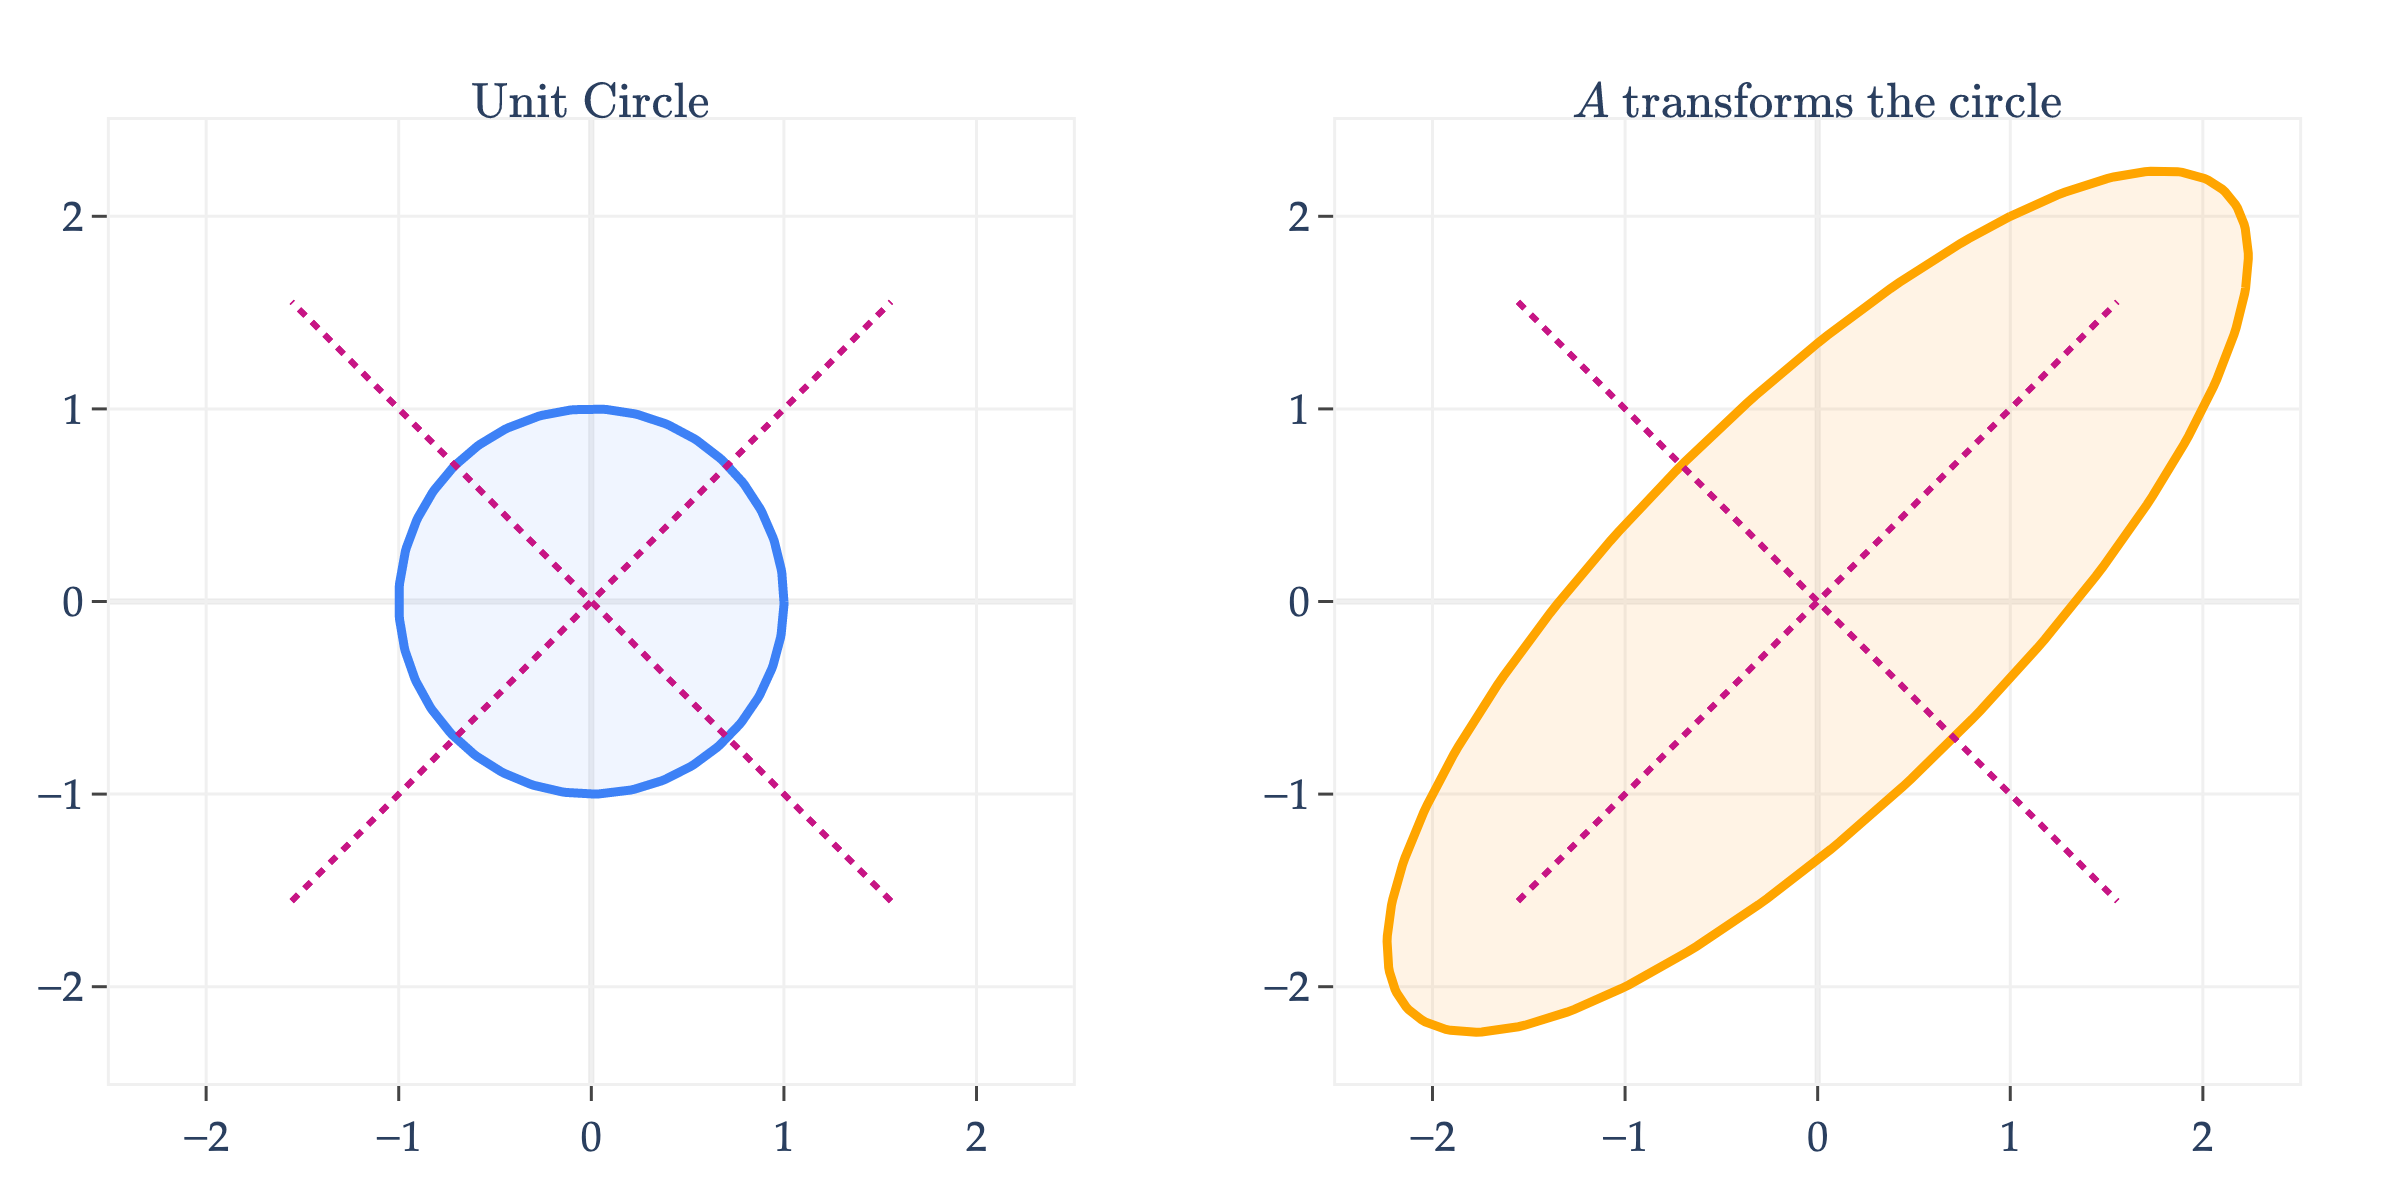

In [32]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_unit_circle_and_transform(S, name="Matrix", show_eig=True, return_fig=False):
    # Generate unit circle points
    theta = np.linspace(0, 2 * np.pi, 300)
    circle = np.vstack((np.cos(theta), np.sin(theta))).T
    # Transformed circle (ellipse)
    ellipse = (S @ circle.T).T

    # Compute real eigenvalues and eigenvectors (for drawing axes)
    try:
        eigvals, eigvecs = np.linalg.eig(S)
    except np.linalg.LinAlgError:
        eigvals, eigvecs = None, None
    # Only retain real-valued eigenvectors for the plot
    real_mask = np.abs(np.imag(eigvals)) < 1e-8
    real_eigvecs = np.real(eigvecs[:, real_mask])
    real_eigvals = np.real(eigvals[real_mask])
    # Normalize eigenvectors for plotting (unit)
    if real_eigvecs.shape[1] > 0:
        eigvec_norms = np.linalg.norm(real_eigvecs, axis=0)
        eigvecs_dir = real_eigvecs / eigvec_norms
    else:
        eigvecs_dir = np.zeros((2,0))

    # Set up figure
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(r"$$\text{Unit Circle}$$", fr"$${name}\ \text{{transforms the circle}}$$"),
        horizontal_spacing=0.08
    )

    # Common axis settings: [-2.5,2.5] for each
    axis_style = dict(
        showgrid=True,
        gridcolor="#f0f0f0",
        zeroline=False,
        showline=True,
        linecolor="#f0f0f0",
        mirror=True,
        ticks="outside",
        showticklabels=True,
        tickfont=dict(family="Palatino, serif", size=14),
    )
    for i in [1, 2]:
        fig.update_xaxes(
            range=[-2.5, 2.5],
            constrain="domain",
            dtick=1,
            **axis_style,
            row=1, col=i
        )
        fig.update_yaxes(
            range=[-2.5, 2.5],
            scaleanchor=f"x{i}",
            dtick=1,
            **axis_style,
            row=1, col=i
        )

    # Grid zero lines under all objects
    for i in [1,2]:
        fig.add_shape(
            type="line",
            x0=-2.5, x1=2.5, y0=0, y1=0,
            line=dict(color="rgba(170,170,170,0.25)", width=2, dash="solid"),
            row=1, col=i,
            layer="below"
        )
        fig.add_shape(
            type="line",
            x0=0, x1=0, y0=-2.5, y1=2.5,
            line=dict(color="rgba(170,170,170,0.25)", width=2, dash="solid"),
            row=1, col=i,
            layer="below"
        )

    # Left: unit circle (blue)
    fig.add_trace(
        go.Scatter(
            x=circle[:,0], y=circle[:,1],
            line=dict(color="#3d81f6", width=3),
            fill="toself",
            fillcolor="rgba(61,129,246,0.08)",
            name="Unit Circle",
            showlegend=False
        ),
        row=1, col=1
    )
    # Right: transformed circle (ellipse, orange)
    fig.add_trace(
        go.Scatter(
            x=ellipse[:,0], y=ellipse[:,1],
            line=dict(color="orange", width=3),
            fill="toself",
            fillcolor="rgba(255,140,0,0.10)",
            name="Transformed Circle",
            showlegend=False
        ),
        row=1, col=2
    )

    # Plot dotted lines for the (real) eigenvector directions
    scale = 2.2
    if show_eig and eigvecs_dir.shape[1] > 0:
        for i in range(eigvecs_dir.shape[1]):
            v = eigvecs_dir[:,i]
            # Both directions (±v); lines will extend through the origin
            for sign in [+1, -1]:
                fig.add_trace(
                    go.Scatter(
                        x=[-scale * v[0], scale * v[0]],
                        y=[-scale * v[1], scale * v[1]],
                        mode="lines",
                        line=dict(color="mediumvioletred", width=2, dash="dot"),
                        name="Eigenvector",
                        hoverinfo="skip",
                        showlegend=False
                    ),
                    row=1, col=1
                )
                # Same (transformed) axis on the right: direction is S*v
                v_trans = S @ v
                v_trans_norm = np.linalg.norm(v_trans)
                if v_trans_norm > 1e-10:
                    v_trans_unit = v_trans / v_trans_norm
                    fig.add_trace(
                        go.Scatter(
                            x=[-scale * v_trans_unit[0], scale * v_trans_unit[0]],
                            y=[-scale * v_trans_unit[1], scale * v_trans_unit[1]],
                            mode="lines",
                            line=dict(color="mediumvioletred", width=2, dash="dot"),
                            name="Transformed Eigenvector",
                            hoverinfo="skip",
                            showlegend=False
                        ),
                        row=1, col=2
                    )

    fig.update_layout(
        font=dict(family="Palatino, serif", size=16),
        plot_bgcolor="white",
        paper_bgcolor="white",
        margin=dict(l=20, r=20, t=40, b=20),
        width=800, height=400,
    )

    if return_fig:
        return fig
    fig.show(renderer='png', scale=3)

# Example usage:
A = np.array([[1, 2], [2, 1]])
plot_unit_circle_and_transform(A, name="A")